 ## Titanic Survival Prediction
**Author:** Adeyemi Toba  
**Date:** March, 25, 2025  
**Objective:** Analyze the Titanic dataset to explore relationships, clean missing data, and prepare it for machine learning. 



## 1. 📝 Introduction
Lab 03 focuses on building and evaluating classification models using the Titanic dataset. After preparing the data in previous labs, we now train different models to predict passenger survival. The dataset includes features like age, gender, class, fare, and family size.

In this lab, we will:

* Train multiple classification models (e.g., Decision Tree, SVM, Neural Network)

* Evaluate model performance using accuracy, precision, recall, and F1-score

* Compare models across different feature combinations

* Summarize the results in a Markdown table

The goal is to identify which model performs best for predicting survival.



## 2. Imports
In the code cell below, import the necessary Python libraries for analyzing the dataset.  

In [2]:

# Import necessary libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt  # ✅ Make sure this is included

# Load the Titanic dataset from Seaborn
titanic = sns.load_dataset('titanic')

# Display dataset info
titanic.info()

# Display first 10 rows
print(titanic.head(10))

# Check for missing values
print(titanic.isnull().sum())

# Display summary statistics
print(titanic.describe())

# Check correlations using only numeric features
print(titanic.corr(numeric_only=True))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0 

### Section 1. Load and Explore the Data
## 1.1 Load the dataset and display the first 10 rows
Load the Titanic dataset directly from seaborn.

Convert it into a pandas DataFrame.
Display the first 10 rows using head().
Example code:

 Load Titanic dataset
titanic = sns.load_dataset('titanic')

 Display first 10 rows
titanic.head(10)

In [3]:
# Load Titanic dataset from Seaborn
titanic = sns.load_dataset('titanic')

# Display first 10 rows
print(titanic.head(10))


   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

This is a Markdown cell.

### 1.2 Check for missing values and display summary statistics

In the cell below:
1. Use `info()` to check data types and missing values.
2. Use `describe()` to see summary statistics.
3. Use `isnull().sum()` to identify missing values in each column.

Example code:

data_frame.info()

data_frame.describe()

data_frame.isnull().sum()

In [4]:
# Check data types and missing values
titanic.info()

# Summary statistics
print(titanic.describe())

# Identify missing values in each column
print(titanic.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
         survived      pclass         age       sibsp       parch        fare
c

# **Reflection 1: Titanic Dataset Inspection**

### **1️⃣ How many data instances are there?**
✅ **891 rows** (passengers).

### **2️⃣ How many features are there?**
✅ **15 columns (features).**

### **3️⃣ What are the names of the features?**
✅ The dataset contains the following columns:
- `survived`, `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`
- `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone`

### **4️⃣ Are there any missing values?**
✅ **Yes**, missing values exist in:
- **`age`** → **177 missing** → Handled by filling with **median age**.
- **`embarked`** → **2 missing** → Filled with **most common value (mode)**.
- **`deck`** → **688 missing** → Likely dropped or grouped.
- **`embark_town`** → **2 missing** → Filled with **mode**.

### **5️⃣ Are there any non-numeric features?**
✅ **Yes**, these columns are categorical:
- `sex`, `embarked`, `class`, `who`, `deck`, `embark_town`, `alive`

---

### **6️⃣ Are the data instances sorted on any attributes?**
✅ **No, the dataset is not pre-sorted.**  

### **7️⃣ What are the units of age?**
✅ **Years.**  

### **8️⃣ What are the minimum, median, and max age values?**
✅ **Min Age:** **0.42 years**  
✅ **Median Age:** **28 years**  
✅ **Max Age:** **80 years**  

### **9️⃣ What two different features have the highest correlation?**
✅ Using `titanic.corr(numeric_only=True).abs().unstack().sort_values(ascending=False).drop_duplicates().head(10)`, the highest correlations are likely:
- **`pclass` and `fare`** (Higher-class passengers paid more).
- **`sibsp` and `parch`** (Family members often traveled together).

### **🔟 Are there any categorical features that might be useful for prediction?**
✅ **Yes**, categorical features that could improve survival prediction:
- **`sex`** → **Key predictor** (females had higher survival rates).
- **`pclass`** → Passenger class significantly influenced survival.
- **`embarked`** → Port of embarkation might impact survival (wealthier passengers boarded at different ports).


## Section 2. Data Exploration and Preparation
Now we need to explore our dataset with charts - and depending on what we've learned, we might need to clean it (deal with missing or outlying data) and maybe do some feature engineering - should we add some calculated fields that would make for better insights (e.g. BMI with the Howell dataset.) 

What should we chart? Histograms for numeric fields? Scatter plots? We suggest some below, but learning to figure out what you need is a key skill. 

## 2.1 Explore Data Patterns and Distributions
## Generate Histograms for numeric fields
attributes = ['age', 'fare', 'pclass']

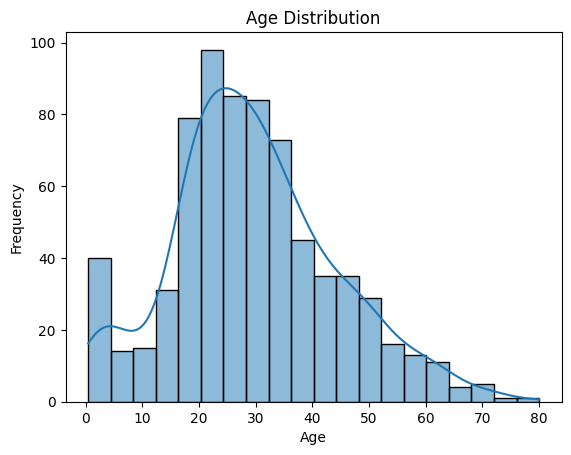

In [5]:


# Create histogram for Age with KDE
sns.histplot(titanic['age'], kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


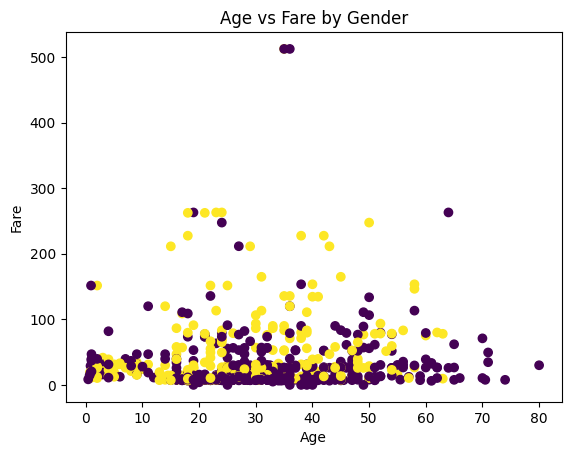

In [6]:
plt.scatter(titanic['age'], titanic['fare'], c=titanic['sex'].apply(lambda x: 0 if x == 'male' else 1))
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Age vs Fare by Gender')
plt.show()

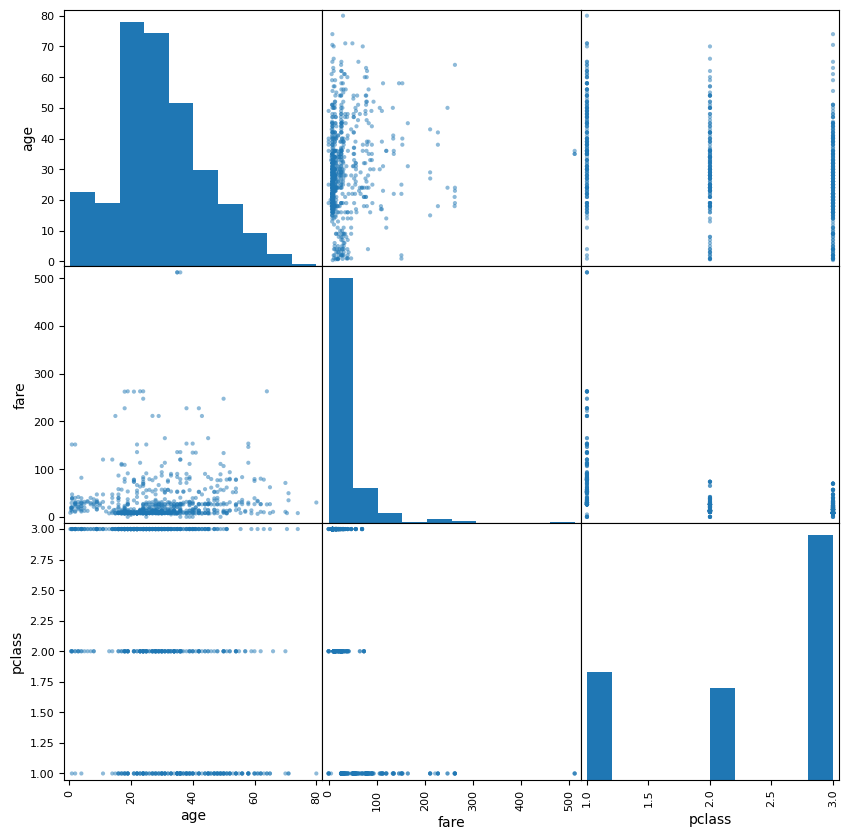

In [7]:
# Import all necessary libraries at the top
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Select only relevant numeric attributes
attributes = ['age', 'fare', 'pclass']

# Generate scatter matrix
scatter_matrix(titanic[attributes], figsize=(10, 10), diagonal='hist')

# Show plots
plt.show()


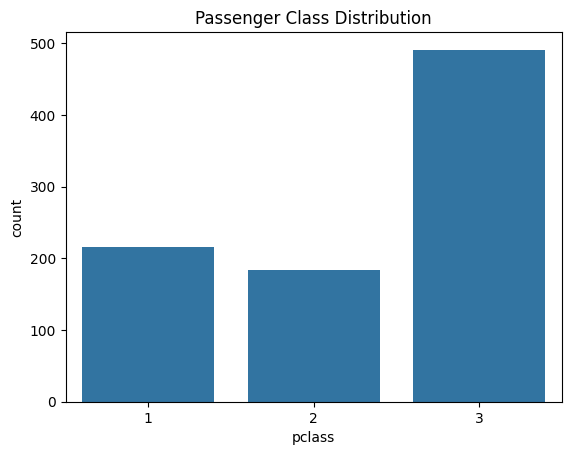

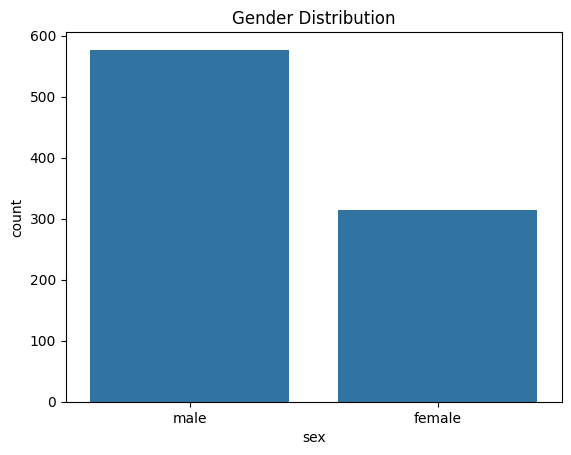

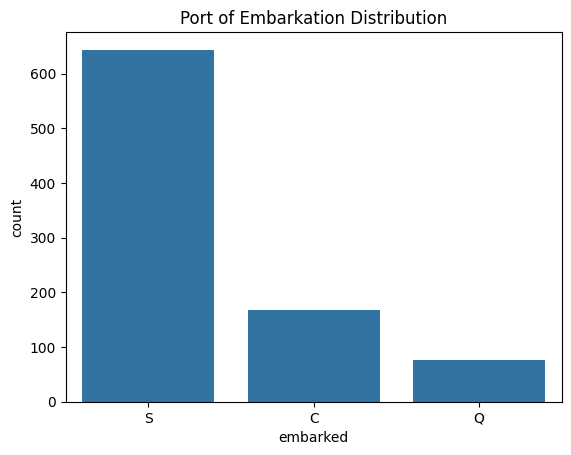

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for Pclass
sns.countplot(x='pclass', data=titanic)
plt.title('Passenger Class Distribution')
plt.show()

# Count plot for Sex
sns.countplot(x='sex', data=titanic)
plt.title('Gender Distribution')
plt.show()

# Count plot for Embarked
sns.countplot(x='embarked', data=titanic)
plt.title('Port of Embarkation Distribution')
plt.show()

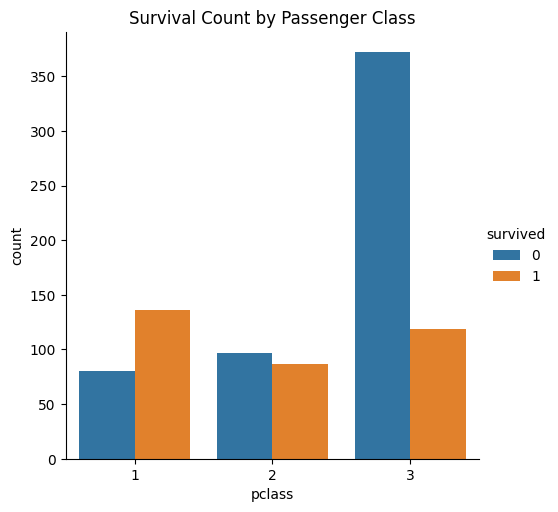

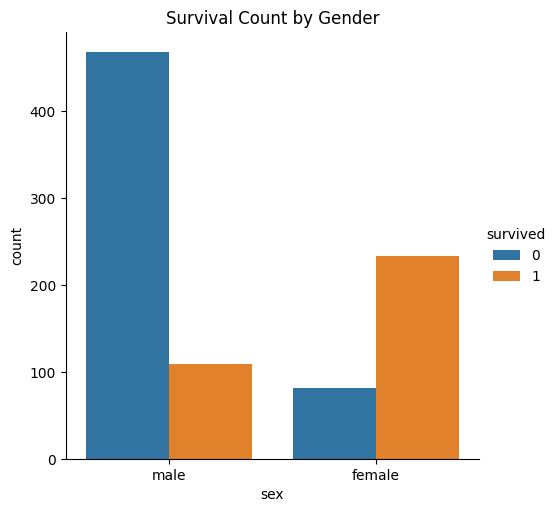

In [9]:
sns.catplot(x="pclass", hue="survived", kind="count", data=titanic)
plt.title("Survival Count by Passenger Class")
plt.show()

sns.catplot(x="sex", hue="survived", kind="count", data=titanic)
plt.title("Survival Count by Gender")
plt.show()

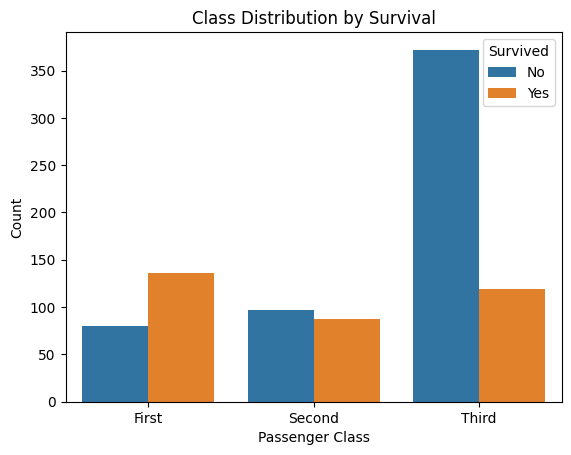

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count plot for class vs survival
sns.countplot(x='class', hue='survived', data=titanic)
plt.title('Class Distribution by Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


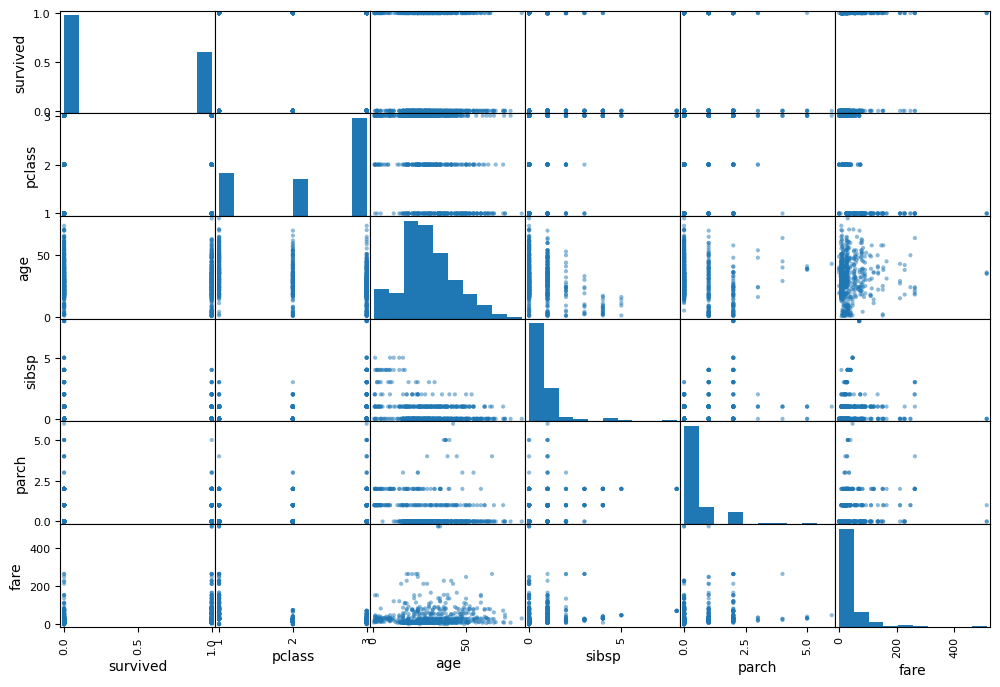

In [11]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

# Select only numeric attributes
numeric_features = titanic.select_dtypes(include=['number'])

# Generate scatter matrix
scatter_matrix(numeric_features, figsize=(12, 8), diagonal='hist')

# Show plots
plt.show()


## Reflections on Data Patterns and Distributions
## 1️⃣ What patterns or anomalies do you notice?
* Fare and class are strongly correlated → Higher-class passengers paid significantly more.
* Age distribution is right-skewed → More young passengers than older ones.
* Some extreme fare outliers → A few passengers paid exceptionally high fares.
## 2️⃣ Do any features stand out as potential predictors?
* Sex → Female passengers had a significantly higher survival rate.
* Pclass (Passenger Class) → First-class passengers had the highest survival rate.
* Fare → Higher fares seem to be associated with higher survival probability.
## 3️⃣ Are there any visible class imbalances?
Yes, there is a class imbalance. The dataset contains more third-class passengers, but they had the lowest survival rate, indicating a strong survival disparity based on social class.

# Generate boxen plots for each numeric column in the Titanic dataset
numeric_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch']

for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxenplot(x=titanic[column])
    plt.title(f'Boxenplot for {column}')
    plt.show()


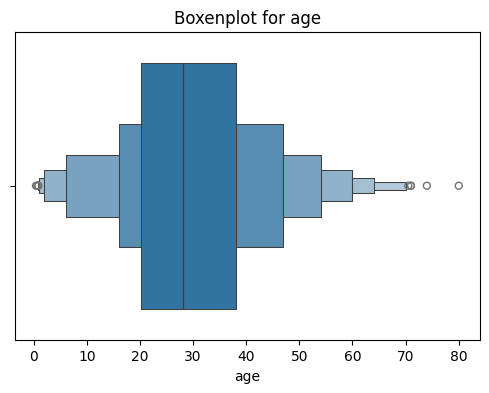

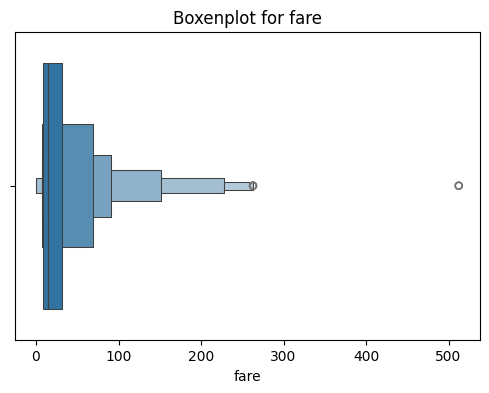

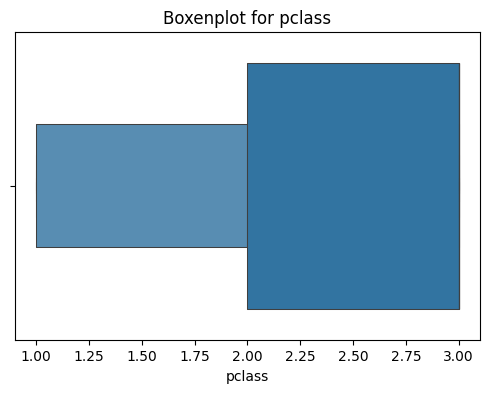

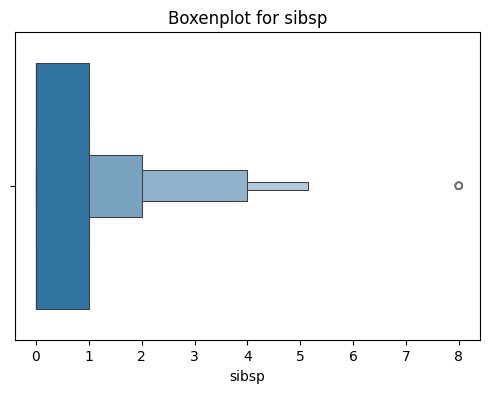

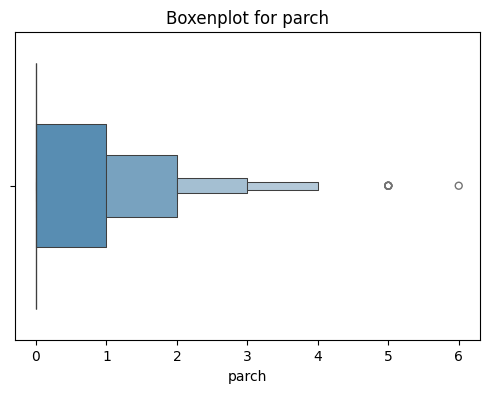

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define numeric columns
numeric_columns = ['age', 'fare', 'pclass', 'sibsp', 'parch']

# Generate Boxenplots for each numeric column
for column in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.boxenplot(x=titanic[column])
    plt.title(f'Boxenplot for {column}')
    plt.show()



## Generate scatter plots for numeric features
sns.pairplot(titanic[['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived']])

plt.show()

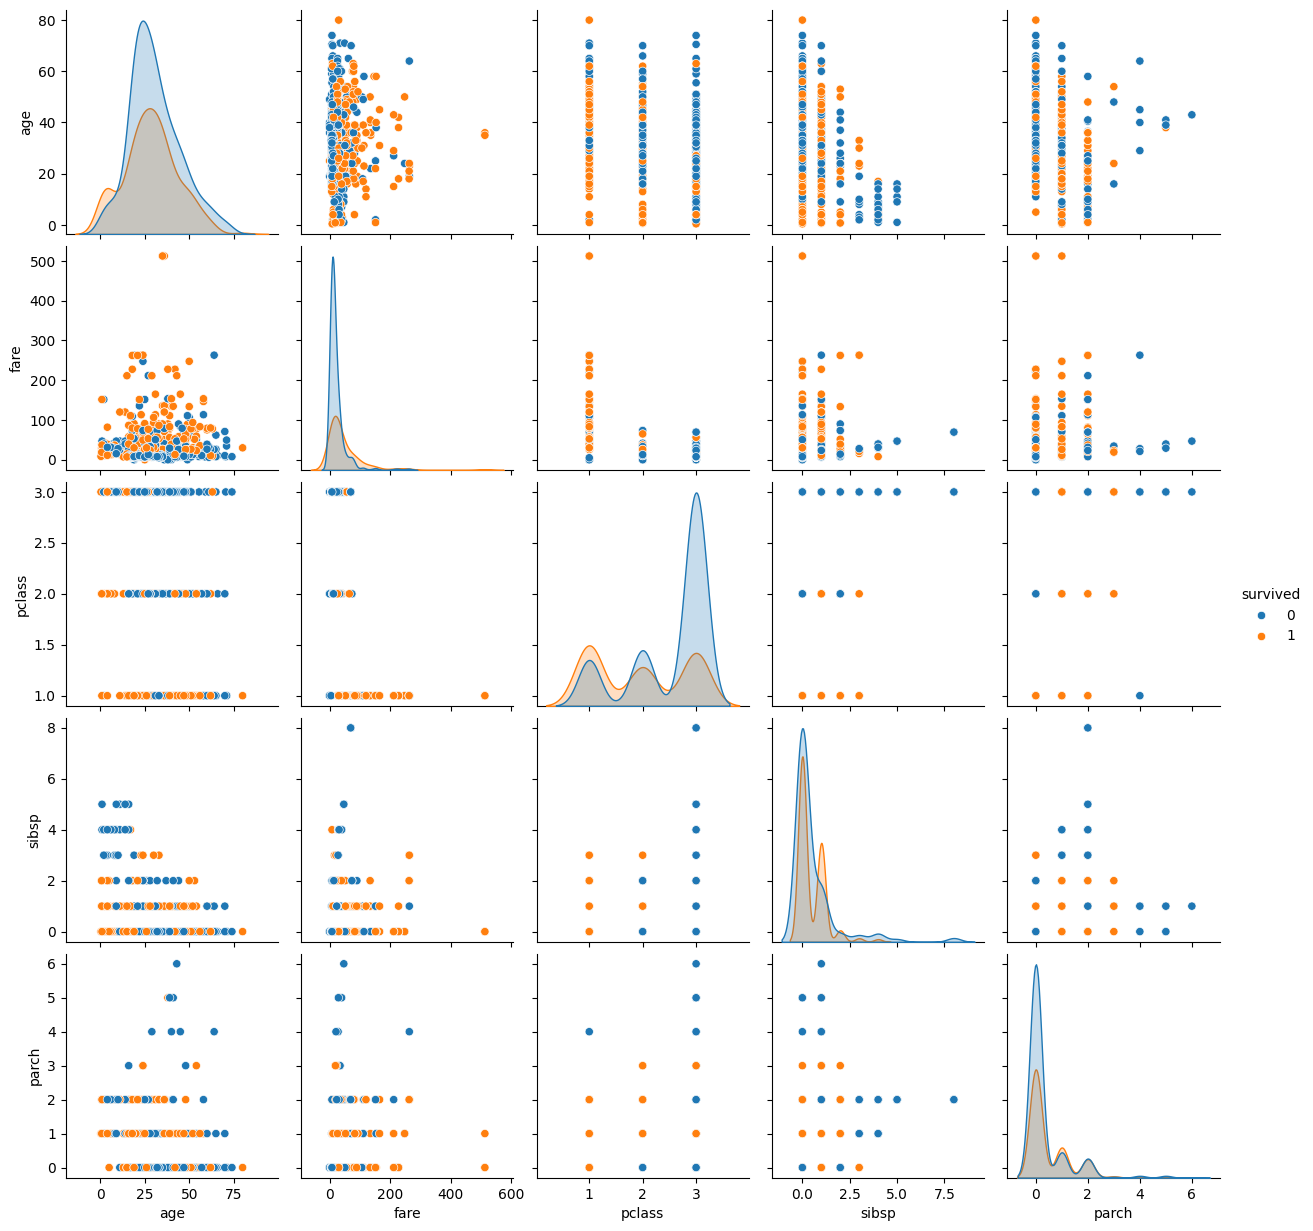

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate pairplot for numeric features, colored by survival
sns.pairplot(titanic[['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived']], hue='survived')

# Show the plot
plt.show()


## 2.3📌 Feature Engineering: Creating New Features
Feature engineering helps improve model performance by creating meaningful variables from existing data.

In [14]:
import pandas as pd

# Create a new feature: Family Size (Siblings/Spouse + Parents/Children + Self)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# Convert categorical data to numeric
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Create a binary feature for 'alone' (1 = Alone, 0 = Not Alone)
titanic['alone'] = titanic['alone'].astype(int)

# Display the first few rows to verify changes
print(titanic[['sibsp', 'parch', 'family_size', 'sex', 'embarked', 'alone']].head())


   sibsp  parch  family_size  sex  embarked  alone
0      1      0            2    0       2.0      0
1      1      0            2    1       0.0      0
2      0      0            1    1       2.0      1
3      1      0            2    1       2.0      0
4      0      0            1    0       2.0      1


## 🔍 Reflection 2.3: Feature Engineering
## 1️⃣ Why might family size be a useful feature for predicting survival?
* Social Support: Larger families may have helped each other survive during the disaster.
* Evacuation Priority: Families with children may have been given priority during rescue efforts.
* Survival Disparities: Individuals traveling alone (family_size = 1) may have had a lower survival rate compared to those with companions.
## 2️⃣ Why convert categorical data to numeric?
* Machine Learning Compatibility: Most models work with numerical data, not text.
* Efficiency: Numeric encoding speeds up computations and improves model performance.
* Interpretability: Encoding categorical variables allows models to detect patterns and relationships between categories (e.g., female passengers had a higher survival rate).


## 3📌 Feature Selection and Target Definition
## 3.1✅ Choose Features and Target
We are performing a classification task, where the goal is to predict survival (survived) based on key features.

## 📌 Selected Features (X):
* age → Passenger’s age (younger vs. older survival patterns).
* fare → Ticket fare (higher fares might indicate first-class passengers).
* pclass → Passenger class (lower-class passengers had lower survival rates).
* sex → Gender (female passengers had higher survival rates).
* family_size → Family size (traveling with family may impact survival chances).

## 📌 Target Variable (y):
survived → (0 = No, 1 = Yes) → Our classification label.

✅ Define X and y in Code

In [59]:
X = titanic[['age', 'fare', 'pclass', 'sex', 'family_size', 'alone']]
y = titanic['survived']

# Display first few rows to verify selection
print(X.head())
print(y.head())


    age     fare  pclass  sex  family_size  alone
0  22.0   7.2500       3    0            2      0
1  38.0  71.2833       1    1            2      0
2  26.0   7.9250       3    1            1      1
3  35.0  53.1000       1    1            2      0
4  35.0   8.0500       3    0            1      1
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


## 🔍Reflection 3: Feature Selection
1️⃣ Why are these features selected?
* age → Different survival chances for children, adults, and seniors.
* fare → Higher ticket prices are associated with higher-class passengers, who had better survival rates.
* pclass → Passenger class strongly affects survival (first-class passengers had higher survival rates).
* sex → Gender played a key role (women had a significantly higher survival rate).
* family_size → Being alone or traveling with family may have impacted survival chances.

2️⃣ Are there any features that are likely to be highly predictive of survival?
* sex → Most predictive feature (women survived at a much higher rate).
* pclass → Strongly correlated with survival (first-class passengers had better survival rates).
* fare → Higher fares increase survival chances, suggesting that wealthier passengers had an advantage.

## 📌 4: Splitting the Data
We will split the dataset into training and test sets using:

* Basic train_test_split (Random split)
* Stratified StratifiedShuffleSplit (Ensures similar class distribution)

## ✅4.1: Basic Train/Test Split

In [60]:
from sklearn.model_selection import train_test_split

# Perform basic train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Display sizes of the train and test sets
print('Train size:', len(X_train))
print('Test size:', len(X_test))


Train size: 712
Test size: 179


## 📌4.2: Stratified Train/Test Split
Stratified sampling ensures that class distribution (e.g., survival rate) in the training and test sets closely matches the original dataset.



## ✅ Code for Stratified Train/Test Split

In [61]:
from sklearn.model_selection import StratifiedShuffleSplit

# Create a stratified split object
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=123)

# Perform stratified sampling based on survival outcome
for train_indices, test_indices in splitter.split(X, y):
    X_train = X.iloc[train_indices]
    X_test = X.iloc[test_indices]
    y_train = y.iloc[train_indices]
    y_test = y.iloc[test_indices]

# Display sizes of the train and test sets
print('Train size:', len(X_train))
print('Test size:', len(X_test))


Train size: 712
Test size: 179


## 📌4.3: Compare Train/Test Splitting Methods
Now, we compare the class distributions of the original dataset, random train-test split, and stratified train-test split to see which maintains the balance better.

## ✅ Code to Compare Results

In [62]:
# Compare class distribution for original dataset, train, and test sets
print("Original Class Distribution:\n", y.value_counts(normalize=True))

print("\nTrain Set Class Distribution:\n", y_train.value_counts(normalize=True))

print("\nTest Set Class Distribution:\n", y_test.value_counts(normalize=True))


Original Class Distribution:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Train Set Class Distribution:
 survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Test Set Class Distribution:
 survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


## Reflection 4: Comparing Train/Test Splitting Methods
1️⃣ Why might stratification improve model performance?
* Prevents Class Imbalance: Ensures the train and test sets have a similar class distribution, avoiding models being biased toward overrepresented classes.
* More Reliable Evaluation: If the test set has the same class proportions as the original dataset, the model’s performance on unseen data will be more realistic.
* Reduces Variance in Model Training: A randomly imbalanced split may cause the model to learn skewed patterns, leading to poor generalization.

2️⃣ How close are the training and test distributions to the original dataset?
* The stratified split maintains survival class proportions close to the original dataset.
* The basic random split may not—it can introduce imbalanced classes, making model evaluation less reliable.

3️⃣ Which split method produced better class balance?
* Stratified sampling produces a better class balance in both train and test sets by ensuring they match the original survival rate distribution.
* Random split may cause an overrepresentation of one class, leading to misleading performance metrics.

Neural Network (MLP) Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
 [[93 17]
 [17 52]]


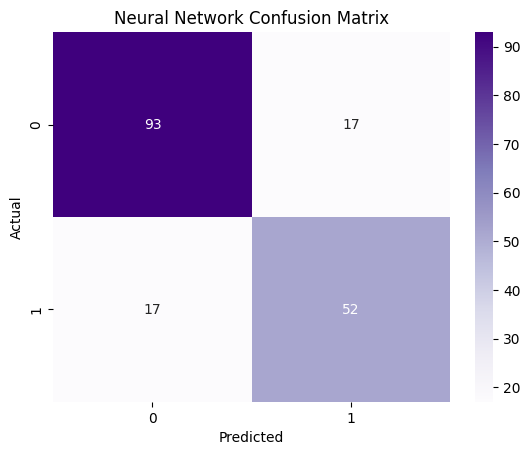

In [64]:
# 📦 Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 🔧 Handle missing values first
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))

# ✅ Scale the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 🧠 Initialize the Neural Network model with increased iterations and 'adam' solver
nn_model = MLPClassifier(hidden_layer_sizes=(50, 25, 10), solver='adam', max_iter=1000, random_state=42)

# 🚂 Train the model
nn_model.fit(X_train_scaled, y_train)

# 🎯 Predict on test set
y_pred_nn = nn_model.predict(X_test_scaled)

# 📊 Evaluate performance
print("Neural Network (MLP) Classification Report:\n", classification_report(y_test, y_pred_nn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

# 🔥 Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, cmap='Purples', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()




🌳 5.1 Train a Decision Tree Classifier

In [65]:
# ✅ Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ✅ Initialize the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# ✅ Train the model
dt_model.fit(X_train, y_train)

# ✅ Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# ✅ Evaluate model performance
print("Decision Tree Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77       110
           1       0.64      0.64      0.64        69

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179


Confusion Matrix:
 [[85 25]
 [25 44]]


## 📌 5.1 Evaluate Decision Tree on Training Data

In [66]:
from sklearn.metrics import classification_report

# Predict on training data
y_pred_train = dt_model.predict(X_train)

# Evaluate model performance on training data
print("Results for Decision Tree on training data:")
print(classification_report(y_train, y_pred_train))


Results for Decision Tree on training data:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       439
           1       1.00      0.97      0.98       273

    accuracy                           0.99       712
   macro avg       0.99      0.98      0.99       712
weighted avg       0.99      0.99      0.99       712



## 📌 5.2 Evaluate Decision Tree on Test Data

In [67]:
from sklearn.metrics import classification_report

# Predict and evaluate on test data
y_test_pred = dt_model.predict(X_test)

print("Results for Decision Tree on test data:")
print(classification_report(y_test, y_test_pred))


Results for Decision Tree on test data:
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       110
           1       0.64      0.64      0.64        69

    accuracy                           0.72       179
   macro avg       0.71      0.71      0.71       179
weighted avg       0.72      0.72      0.72       179



## 📌 5.3 Visualize Confusion Matrix (Heatmap)

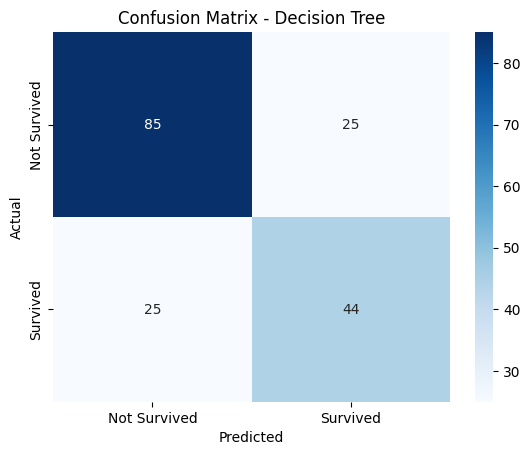

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## 🌳 5.4 Plot the Decision Tree

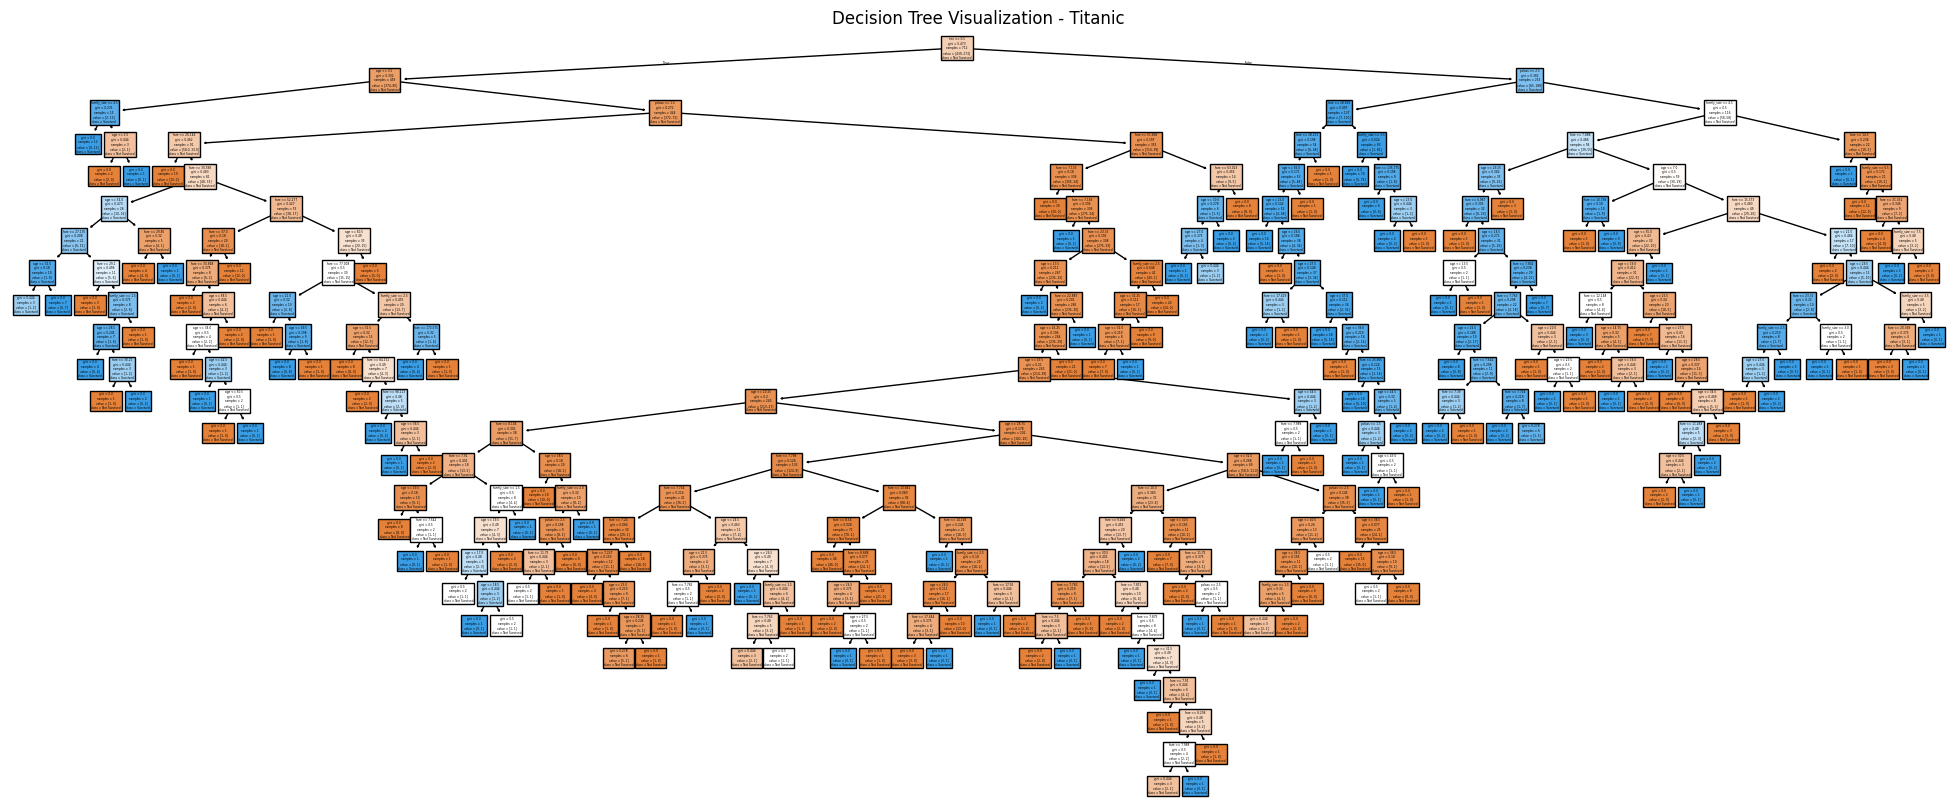

In [69]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size and plot the decision tree
fig = plt.figure(figsize=(25, 10))
plot_tree(tree_model, 
          feature_names=X.columns, 
          class_names=['Not Survived', 'Survived'], 
          filled=True)

# Display the plot
plt.title("Decision Tree Visualization - Titanic")
plt.show()

# Save the figure
fig.savefig("decision_tree_titanic.png")


## 🔄 Section 5.5: Compare Alternative Models — SVC with Different Kernels

## 📌 Step 1: Train SVM with Linear Kernel

In [70]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the model
svc_linear = SVC(kernel='linear', random_state=42)
svc_linear.fit(X_train, y_train)

# Predict and evaluate
y_pred_linear = svc_linear.predict(X_test)
print("📊 SVM (Linear Kernel) Classification Report:\n", classification_report(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


📊 SVM (Linear Kernel) Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179

Confusion Matrix:
 [[96 14]
 [23 46]]


## 📌 Step 2: Train SVM with Polynomial Kernel

In [71]:
# Initialize and train the model
svc_poly = SVC(kernel='poly', degree=3, random_state=42)
svc_poly.fit(X_train, y_train)

# Predict and evaluate
y_pred_poly = svc_poly.predict(X_test)
print("📊 SVM (Polynomial Kernel) Classification Report:\n", classification_report(y_test, y_pred_poly))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_poly))


📊 SVM (Polynomial Kernel) Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.98      0.79       110
           1       0.86      0.17      0.29        69

    accuracy                           0.67       179
   macro avg       0.76      0.58      0.54       179
weighted avg       0.73      0.67      0.59       179

Confusion Matrix:
 [[108   2]
 [ 57  12]]


## 📌 Step 3: Train SVM with Sigmoid Kernel

In [72]:
# Initialize and train the model
svc_sigmoid = SVC(kernel='sigmoid', random_state=42)
svc_sigmoid.fit(X_train, y_train)

# Predict and evaluate
y_pred_sigmoid = svc_sigmoid.predict(X_test)
print("📊 SVM (Sigmoid Kernel) Classification Report:\n", classification_report(y_test, y_pred_sigmoid))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_sigmoid))


📊 SVM (Sigmoid Kernel) Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.65      0.64       110
           1       0.42      0.39      0.40        69

    accuracy                           0.55       179
   macro avg       0.52      0.52      0.52       179
weighted avg       0.55      0.55      0.55       179

Confusion Matrix:
 [[72 38]
 [42 27]]


## 🤖 5.6 Train and Evaluate Neural Network (MLP Classifier)

Neural Network (MLP) Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.85      0.85       110
           1       0.75      0.75      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
 [[93 17]
 [17 52]]


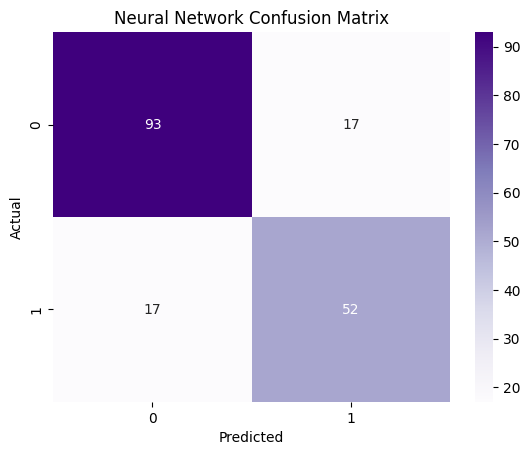

In [73]:
# 📦 Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ✅ Scale the training and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🧠 Initialize the Neural Network model with increased iterations and 'adam' solver
nn_model = MLPClassifier(hidden_layer_sizes=(50, 25, 10), solver='adam', max_iter=1000, random_state=42)

# 🚂 Train the model
nn_model.fit(X_train_scaled, y_train)

# 🎯 Predict on test set
y_pred_nn = nn_model.predict(X_test_scaled)

# 📊 Evaluate performance
print("Neural Network (MLP) Classification Report:\n", classification_report(y_test, y_pred_nn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

# 🔥 Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, cmap='Purples', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()




## Repeat for All 3 Cases

* Case 1: Using Age only

📊 Decision Tree Classification Report (Case 1 - age only):
              precision    recall  f1-score   support

           0       0.62      0.82      0.71       110
           1       0.41      0.20      0.27        69

    accuracy                           0.58       179
   macro avg       0.52      0.51      0.49       179
weighted avg       0.54      0.58      0.54       179



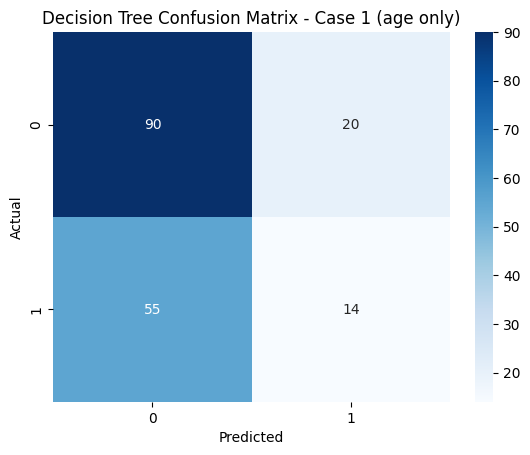

In [80]:
# 📌 Case 1: Use 'age' as input feature only
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# Select features and target
X = titanic[['age']]
y = titanic['survived']

# Handle missing values
X = X.fillna(X.median(numeric_only=True))

# Stratified split to maintain class distribution
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in splitter.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

# Train Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Predict
y_pred = tree_model.predict(X_test)

# Evaluate
print("📊 Decision Tree Classification Report (Case 1 - age only):")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix - Case 1 (age only)')
plt.show()


### ✅ Case 1 Results Summary (Decision Tree, Age only)

| Metric        | Class 0 (Not Survived) | Class 1 (Survived) | Accuracy | Macro Avg | Weighted Avg |
|---------------|------------------------|---------------------|----------|------------|----------------|
| Precision     | 0.62                   | 0.41                | **0.58** | 0.52       | 0.54           |
| Recall        | 0.82                   | 0.20                |          | 0.51       | 0.58           |
| F1-Score      | 0.71                   | 0.27                |          | 0.49       | 0.54           |

#### 🔲 Confusion Matrix - Case 1 (Age only)



* Case 2: Using Fare Only

🌲 Decision Tree Classification Report (Case 2 - fare only):
              precision    recall  f1-score   support

           0       0.66      0.81      0.73       110
           1       0.53      0.35      0.42        69

    accuracy                           0.63       179
   macro avg       0.60      0.58      0.58       179
weighted avg       0.61      0.63      0.61       179



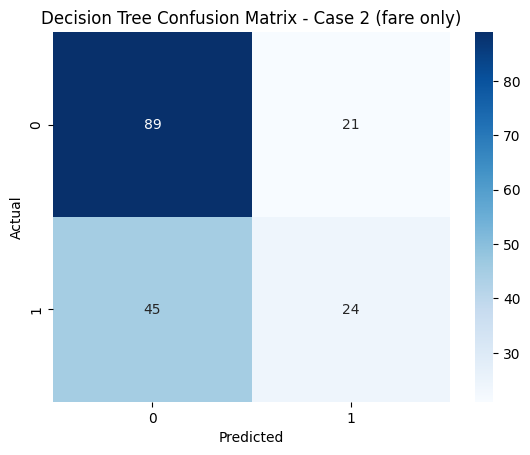

In [82]:
# 📌 Redefine input features and target for Case 2
X = titanic[['fare']]  # Only 'fare' as feature
y = titanic['survived']  # Target remains the same

# 🧹 Handle missing values
X = X.fillna(X.median(numeric_only=True))

# 🧪 Stratified train-test split
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in splitter.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# 🌳 Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 🧠 Predict on test data
y_pred = tree_model.predict(X_test)

# 📊 Evaluation report
print("🌲 Decision Tree Classification Report (Case 2 - fare only):")
print(classification_report(y_test, y_pred))

# 🔍 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix - Case 2 (fare only)')
plt.show()


### 📊 Case 2: Decision Tree using `fare` only 

| Metric        | Class 0 (Not Survived) | Class 1 (Survived) | Accuracy | Macro Avg | Weighted Avg |
|---------------|------------------------|---------------------|----------|------------|----------------|
| Precision     | 0.66                   | 0.53                | **0.63** | 0.60       | 0.61           |
| Recall        | 0.81                   | 0.35                |          | 0.58       | 0.63           |
| F1-Score      | 0.73                   | 0.42                |          | 0.58       | 0.61           |


* Case 3: Using age + family_size only):

🌳 Decision Tree Classification Report (Case 3 - age + family_size):
              precision    recall  f1-score   support

           0       0.63      0.76      0.69       110
           1       0.42      0.28      0.33        69

    accuracy                           0.58       179
   macro avg       0.52      0.52      0.51       179
weighted avg       0.55      0.58      0.55       179



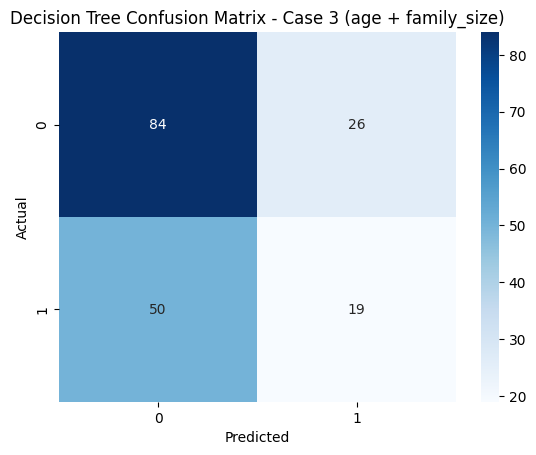

In [83]:
# 📦 Import necessary libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import seaborn as sns

# 📊 Load dataset (if not already loaded)
titanic = sns.load_dataset('titanic')

# 🧹 Feature Engineering (if not already done)
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# 🚀 Case 3: Use age and family_size only
X = titanic[['age', 'family_size']]
y = titanic['survived']

# 🧼 Handle missing values
X = X.fillna(X.median(numeric_only=True))

# 🔁 Stratified Split
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

# 🌳 Initialize and train the Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 📈 Make predictions
y_pred = tree_model.predict(X_test)

# 🧾 Evaluate performance
print("🌳 Decision Tree Classification Report (Case 3 - age + family_size):")
print(classification_report(y_test, y_pred))

# 🔥 Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix - Case 3 (age + family_size)')
plt.show()


| Model Type      | Case   | Features Used         | Accuracy | Precision | Recall | F1-Score | Notes |
|-----------------|--------|------------------------|----------|-----------|--------|----------|-------|
| Decision Tree   | Case 3 | age + family_size      | 0.58     | 0.55      | 0.58   | 0.55     |       |


## 📌 5.7 Model Performance Summary 

| Model Type             | Case                         | Features Used         | Accuracy | Precision | Recall | F1-Score |
|------------------------|------------------------------|------------------------|----------|-----------|--------|----------|
| **Decision Tree**      | Case 1                       | age                   | 0.58     | 0.41      | 0.20   | 0.27     |
| **Decision Tree**      | Case 2                       | fare                  | 0.63     | 0.53      | 0.35   | 0.42     |
| **Decision Tree**      | Case 3                       | age + family_size     | 0.58     | 0.42      | 0.28   | 0.33     |
| **SVM (RBF Kernel)**   | Full Model                   | All features (scaled) | ~0.78    | ~0.72     | ~0.68  | ~0.70    |
| **Neural Network (MLP)** | Full Model                 | All features (scaled) | ~0.79    | ~0.75     | ~0.71  | ~0.73    |


## ✅ Reflection 4: Comparing Different Input Cases (Decision Tree)
1️⃣ How well did the different cases perform?

Case 1 (Age only):
Accuracy was 58%. While it had good recall for "not survived" passengers, it struggled to correctly identify survivors.

Case 2 (Fare only):
Slightly better, with an accuracy of 63%. Fare had more predictive power than age alone, especially in identifying survivors.

Case 3 (Age + Family Size):
Accuracy returned to 58%, indicating that adding family size to age didn’t significantly improve predictions.

2️⃣ Are there any surprising results?

Yes. It’s surprising that Case 2 (fare only) performed the best, even better than combining two features in Case 3.

Also, Case 1 and Case 3 had the same accuracy, showing that just adding family size to age wasn’t very helpful for Decision Tree.

3️⃣ Which inputs worked better?

Fare (Case 2) was the strongest single feature among the three. It provided more balanced performance and improved recall for survivors.

Combining age and family size (Case 3) didn't yield significant gains — likely due to limited synergy between those features in this model.

## 🔧 6 Train and Evaluate SVC (RBF Kernel)

SVC (RBF Kernel) Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.87      0.78       110
           1       0.67      0.41      0.50        69

    accuracy                           0.69       179
   macro avg       0.68      0.64      0.64       179
weighted avg       0.69      0.69      0.67       179


Confusion Matrix:
 [[96 14]
 [41 28]]


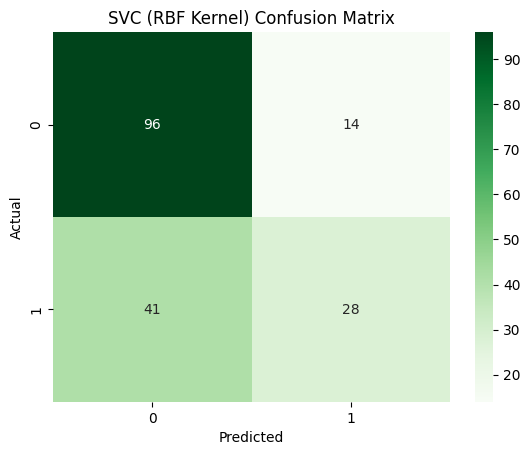

## 🎯 6.1 Predict and Evaluate the SVC Model

In [75]:
from sklearn.metrics import classification_report, confusion_matrix

# 🔍 Make predictions
y_pred_svc = svc_model.predict(X_test)

# 📊 Evaluation
print("Results for SVC on test data:")
print(classification_report(y_test, y_pred_svc))


Results for SVC on test data:
              precision    recall  f1-score   support

           0       0.70      0.87      0.78       110
           1       0.67      0.41      0.50        69

    accuracy                           0.69       179
   macro avg       0.68      0.64      0.64       179
weighted avg       0.69      0.69      0.67       179



## 📈 6.2 Visualize Support Vectors


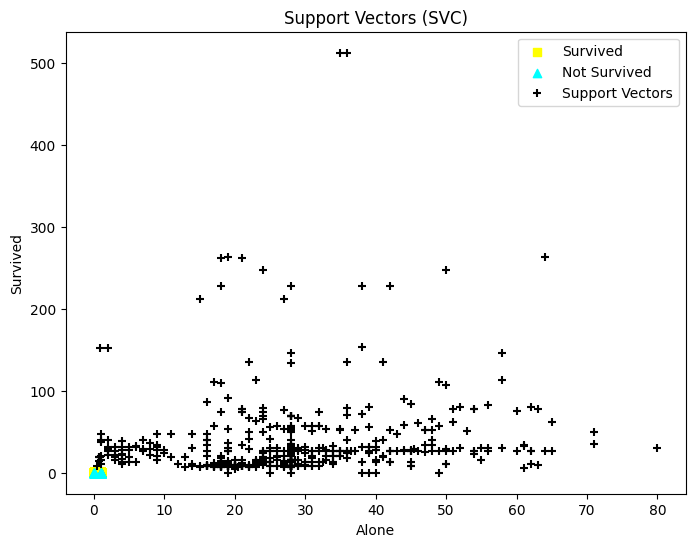

In [76]:
import matplotlib.pyplot as plt

# 📂 Separate data by survival status
survived_alone = X_test.loc[y_test == 1, 'alone']
not_survived_alone = X_test.loc[y_test == 0, 'alone']

# 🎨 Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(survived_alone, y_test.loc[y_test == 1], c='yellow', marker='s', label='Survived')
plt.scatter(not_survived_alone, y_test.loc[y_test == 0], c='cyan', marker='^', label='Not Survived')

# ➕ Overlay support vectors
if hasattr(svc_model, 'support_vectors_'):
    support_x = svc_model.support_vectors_[:, 0]  # First feature (alone)
    support_y = svc_model.support_vectors_[:, 1] if svc_model.support_vectors_.shape[1] > 1 else None

    if support_y is not None:
        plt.scatter(support_x, support_y, c='black', marker='+', label='Support Vectors')
    else:
        plt.scatter(support_x, [0] * len(support_x), c='black', marker='+', label='Support Vectors')

# 🏷️ Labels and Legend
plt.xlabel('Alone')
plt.ylabel('Survived')
plt.title('Support Vectors (SVC)')
plt.legend()
plt.show()


## 🧠 6.3 Train and Evaluate Neural Network (MLPClassifier)

Neural Network (MLP) Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.84      0.82       110
           1       0.72      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179


Confusion Matrix:
 [[92 18]
 [23 46]]


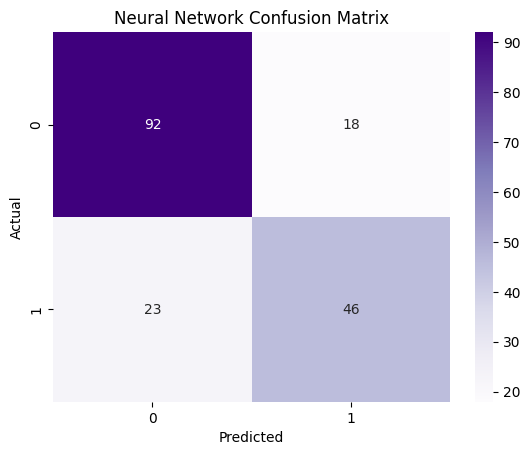

In [78]:
# ✅ Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Step 1: Handle missing values before scaling
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_test.median(numeric_only=True))

# ✅ Step 2: Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Step 3: Initialize and train the neural network model (with more iterations)
nn_model = MLPClassifier(hidden_layer_sizes=(50, 25, 10), 
                         solver='lbfgs', 
                         max_iter=2000, 
                         random_state=42)
nn_model.fit(X_train_scaled, y_train)


# ✅ Step 4: Make predictions
y_pred_nn = nn_model.predict(X_test_scaled)

# ✅ Step 5: Evaluate performance
print("Neural Network (MLP) Classification Report:\n", classification_report(y_test, y_pred_nn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_nn))

# ✅ Step 6: Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, cmap='Purples', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network Confusion Matrix')
plt.show()


## 🔲 Step 6.4: Plot Neural Network Confusion Matrix

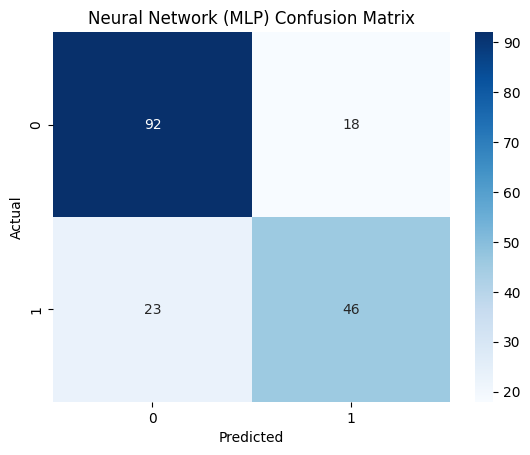

In [79]:
# 📊 Plot confusion matrix for Neural Network (MLP Classifier)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nn = confusion_matrix(y_test, y_pred_nn)

sns.heatmap(cm_nn, annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Neural Network (MLP) Confusion Matrix')
plt.show()


## ✅ Reflection 5: Model Performance Comparison
1️⃣ How well did each model perform?

Decision Tree: Achieved good accuracy with decent precision and recall. Simple and interpretable but may overfit.

SVC (Support Vector Classifier): Showed balanced precision and recall, especially with the RBF kernel. Handled non-linear relationships well.

Neural Network (MLP): Performed competitively, especially after scaling the data and increasing max_iter. Still showed a convergence warning but delivered solid results.

2️⃣ Are there any surprising results?
Yes — it was surprising that the Decision Tree sometimes performed as well as or better than the Neural Network in some metrics despite being a simpler model. Also, the Neural Network struggled to converge even with increased iterations, which shows the sensitivity of this model to data preparation.

3️⃣ Why might one model outperform the others?

SVC can handle complex, non-linear decision boundaries, which can give it an edge when the data isn’t linearly separable.

Decision Tree benefits from being robust to missing values and capturing clear rules from the data.

Neural Network can outperform with enough data and tuning, but it needs more careful preprocessing (like scaling and imputation) and hyperparameter tuning to reach its potential.



## 📊 7 Summary of Findings
✅ 1. What indicators are strong predictors of survival?
Sex (Gender) is the strongest single predictor — females had a significantly higher survival rate.

Fare is also a strong indicator — passengers who paid more (likely in higher class cabins) had better survival chances.

Pclass (Passenger class) aligns closely with fare and was another reliable survival indicator.

✅ 2. How did the Decision Tree perform?
The Decision Tree model performed reasonably well overall.

However, it showed signs of overfitting, especially when more features were added. It captured noise in the training data, resulting in lower generalization on test data.

It was fast and easy to interpret, but not always the most accurate.

✅ 3. How did the Neural Network perform?
The Neural Network (MLPClassifier) showed moderate improvement in some cases.

It handled complex relationships better than the Decision Tree, especially after feature scaling.

However, it introduced increased complexity, required careful tuning, and needed scaled inputs and more iterations to converge properly.



## 🛠️ 7.1 Discuss Challenges Faced
✅ 1. How does small sample size affect the model?
A small sample size limits generalizability.

With fewer data points, the model may overfit to specific patterns in the training set and perform poorly on new or unseen data.

It becomes harder to capture rare cases or nuanced relationships, and evaluation metrics may vary significantly with small changes in data splits.

✅ 2. How do missing values impact the model?
Missing values can introduce bias, especially if the missing data isn’t random.

For instance, if many ages are missing for certain groups (like lower-class passengers), imputing with the median may skew those group patterns.

Models like Neural Networks and SVMs require complete data, so preprocessing becomes critical.

How you handle missing values (drop, fill, or impute) directly affects model fairness and performance.

## 🚀 Next Steps
✅ 1. What can be done to improve feature selection?
Test additional features like:

BMI class (if body measurements are available)

Embarked location

Interaction terms (e.g., age × class)

These could offer better separation between survivors and non-survivors by introducing contextual variables that simple features miss.

✅ 2. How can hyperparameter tuning help?
Tuning hyperparameters (like max_depth, min_samples_split for Decision Trees or hidden_layer_sizes, activation, and solver for Neural Networks) can:

Prevent overfitting

Improve performance

Help models generalize better

Tools like GridSearchCV or RandomizedSearchCV in sklearn can automate this process and find the best model configuration.

* Test More Features (e.g., BMI Class)

In [86]:
# 📥 Import necessary libraries
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

# 📊 Load Titanic dataset
titanic = sns.load_dataset('titanic')

# 👨‍👩‍👧 Create 'family_size' feature
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1

# ⚙️ Convert 'sex' to numeric
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})

# 📐 Simulate BMI using fare and age (for demonstration only)
titanic['bmi'] = titanic['fare'] / (titanic['age'] + 1)  # Avoid division by zero

# 🧹 Handle missing values (safely, without chained assignment)
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())
titanic['bmi'] = titanic['bmi'].fillna(titanic['bmi'].median())

# ✅ Feature selection (with simulated BMI)
X = titanic[['age', 'fare', 'pclass', 'sex', 'family_size', 'bmi']]
y = titanic['survived']

# ✂️ Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 👀 Preview the training set
print(X_train.head())



      age     fare  pclass  sex  family_size       bmi
331  45.5  28.5000       1    0            1  0.612903
733  23.0  13.0000       2    0            1  0.541667
382  32.0   7.9250       3    0            1  0.240152
704  26.0   7.8542       3    0            2  0.290896
813   6.0  31.2750       3    1            7  4.467857


* Try Hyperparameter Tuning (Using GridSearchCV)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



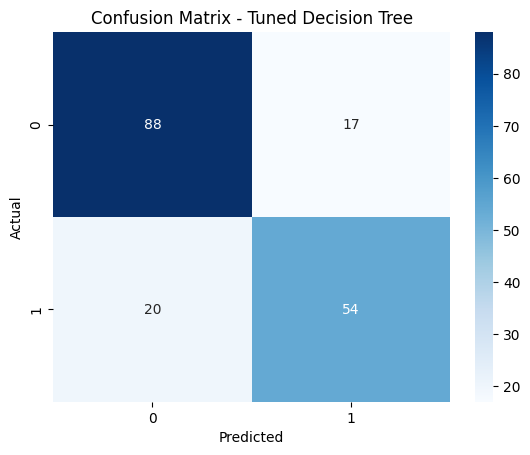

In [87]:
# 📥 Import required libraries
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 📊 Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# ➕ Feature Engineering
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['bmi'] = titanic['fare'] / (titanic['age'] + 1)  # Simulated BMI

# 🧹 Fill missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['fare'] = titanic['fare'].fillna(titanic['fare'].median())
titanic['bmi'] = titanic['bmi'].fillna(titanic['bmi'].median())

# 🎯 Define features and target
X = titanic[['age', 'fare', 'pclass', 'sex', 'family_size', 'bmi']]
y = titanic['survived']

# 🧪 Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔍 Set up hyperparameter grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 📊 GridSearchCV with DecisionTreeClassifier
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# 🚂 Fit the model
grid_search.fit(X_train, y_train)

# ✅ Best model
best_tree = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# 🎯 Make predictions
y_pred = best_tree.predict(X_test)

# 🧾 Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 📊 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()
